# RQ2 — Resolution Strategies

> *How are resolution decisions distributed across conflicting chunks
> (V1, V2, CC, CB, NC, NN, Imprecise), and how does this distribution
> compare to the one reported by Ghiotto et al. for human-authored
> merges?* — PLAN.md §3 (RQ2)

Strategy labels emitted by `identify_resolution` are folded to the
seven-bucket scheme of PLAN.md §5.4 (ConcatV1V2/ConcatV2V1 → CC,
Combination → CB, "New code" → NC, "None" → NN, Postponed → Imprecise).
Ghiotto et al.'s percentages are embedded for the side-by-side
comparison figure (RQ2 §5 of the paper). Figures are saved to
`analysis/figures/` as `.pdf` + `.png`.


In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution,
    STRATEGY_ORDER, STRATEGY_PALETTE,
    RESOLVER_ORDER, RESOLVER_PALETTE,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load data & build the chunk frame

In [2]:
tables = load_tables()
chunks = build_chunk_frame(tables)
print(f"Chunks (classified): {len(chunks):,}")
if not chunks.empty:
    print("\nRaw strategy labels before folding:")
    print(chunks["strategy_raw"].value_counts().to_string())


Chunks (classified): 98,322

Raw strategy labels before folding:
strategy_raw
Imprecise      30791
V1             30689
V2             14561
Postponed       6718
New code        6332
Combination     5507
ConcatV1V2      2508
ConcatV2V1       839
None             377


## 2. Global strategy distribution

In [3]:
global_dist = strategy_distribution(chunks)
global_dist.round(4) * 100   # show as percentages


strategy,V1,V2,CC,CB,NC,NN,Imprecise
all,31.21,14.81,3.4,5.6,6.44,0.38,38.15


## 3. Figure 1 — Global strategy distribution vs. Ghiotto et al.

Side-by-side bar chart; the Ghiotto percentages are the ones reported
in TSE 2020, Figure 10 (aggregated 2,731 Java projects). Note that
Ghiotto does *not* have an "Imprecise" bucket, so their bars sum to
100 % over the other six categories.


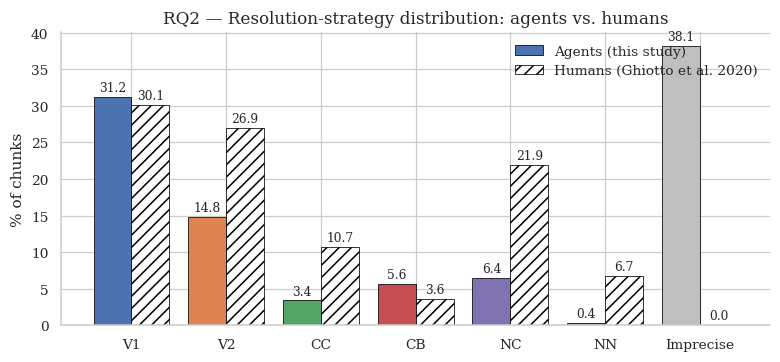

In [4]:
# Ghiotto et al. (TSE 2020), Figure 10 aggregate percentages.
GHIOTTO_HUMAN = {
    "V1": 30.14,
    "V2": 26.95,
    "CC": 10.73,
    "CB":  3.58,
    "NC": 21.86,
    "NN":  6.74,
    "Imprecise": 0.00,   # not reported in Ghiotto; kept as 0 for alignment
}

if chunks.empty:
    print("No classified chunks yet -- run the pipeline first.")
else:
    agent_pct = (global_dist.iloc[0].reindex(STRATEGY_ORDER).fillna(0) * 100)
    human_pct = pd.Series(GHIOTTO_HUMAN).reindex(STRATEGY_ORDER).fillna(0)

    x = np.arange(len(STRATEGY_ORDER))
    w = 0.4
    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    ax.bar(x - w/2, agent_pct.values, width=w,
           color=[STRATEGY_PALETTE[s] for s in STRATEGY_ORDER],
           edgecolor="black", linewidth=0.5, label="Agents (this study)")
    ax.bar(x + w/2, human_pct.values, width=w,
           color="white", edgecolor="black", hatch="///",
           linewidth=0.5, label="Humans (Ghiotto et al. 2020)")
    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_ylabel("% of chunks")
    ax.set_title("RQ2 — Resolution-strategy distribution: agents vs. humans")
    ax.legend(loc="upper right")
    for i, v in enumerate(agent_pct.values):
        ax.text(x[i] - w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    for i, v in enumerate(human_pct.values):
        ax.text(x[i] + w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    save_fig(fig, "rq2_global_vs_ghiotto")
    plt.show()


## 4. Figure 2 — Strategy distribution by agent (stacked bars)

Each column is an agent; segment colours are the canonical strategies.
The numerical counts of chunks per agent are printed alongside so the
reader can calibrate how much weight each bar carries.


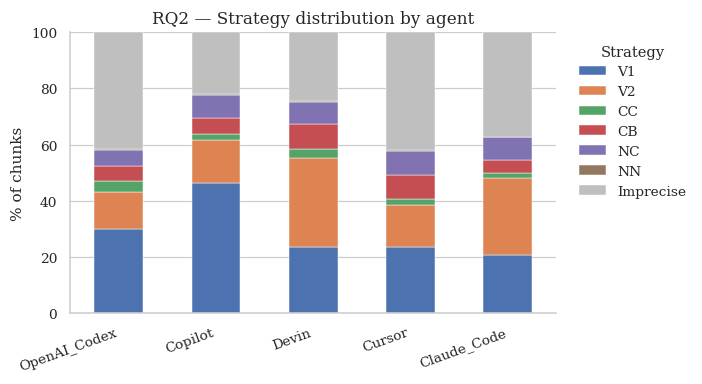

Chunks per agent:
agent
OpenAI_Codex    77598
Copilot         12142
Devin            4903
Cursor           2651
Claude_Code      1028


In [5]:
if not chunks.empty and "agent" in chunks.columns:
    by_agent = strategy_distribution(chunks, group_col="agent")
    by_agent = by_agent.loc[
        chunks["agent"].fillna("Unknown").value_counts().index.intersection(by_agent.index)
    ]

    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(by_agent) + 2), 3.6))
    (by_agent * 100).plot(
        kind="bar", stacked=True,
        color=[STRATEGY_PALETTE[s] for s in STRATEGY_ORDER],
        edgecolor="white", linewidth=0.3, ax=ax,
    )
    ax.set_ylabel("% of chunks")
    ax.set_xlabel("")
    ax.set_title("RQ2 — Strategy distribution by agent")
    ax.set_ylim(0, 100)
    ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, "rq2_by_agent")
    plt.show()

    print("Chunks per agent:")
    print(chunks["agent"].value_counts().to_string())


## 5. Figure 3 — Strategy distribution by language (top-N)

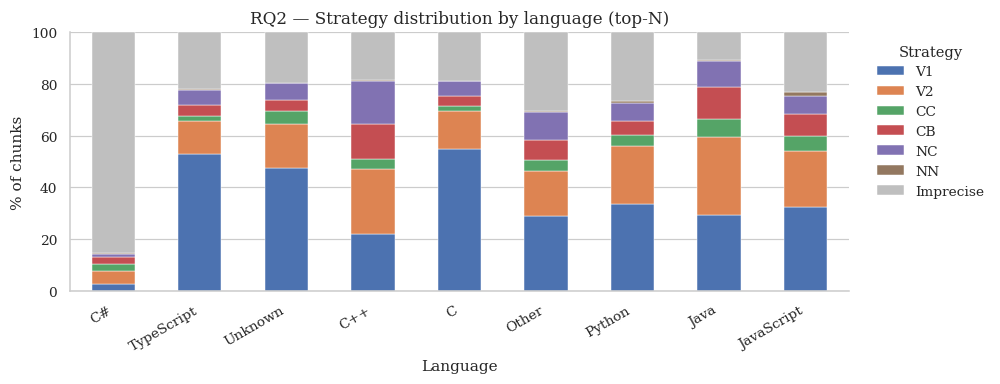

In [6]:
if not chunks.empty and "language_top" in chunks.columns:
    by_lang = strategy_distribution(chunks, group_col="language_top")
    order = chunks["language_top"].fillna("Unknown").value_counts().index
    by_lang = by_lang.reindex(order)

    fig, ax = plt.subplots(figsize=(max(6, 0.8 * len(by_lang) + 2), 3.6))
    (by_lang * 100).plot(
        kind="bar", stacked=True,
        color=[STRATEGY_PALETTE[s] for s in STRATEGY_ORDER],
        edgecolor="white", linewidth=0.3, ax=ax,
    )
    ax.set_ylabel("% of chunks")
    ax.set_xlabel("Language")
    ax.set_title("RQ2 — Strategy distribution by language (top-N)")
    ax.set_ylim(0, 100)
    ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "rq2_by_language")
    plt.show()


## 6. Figure 4 — Strategy distribution by PR task type

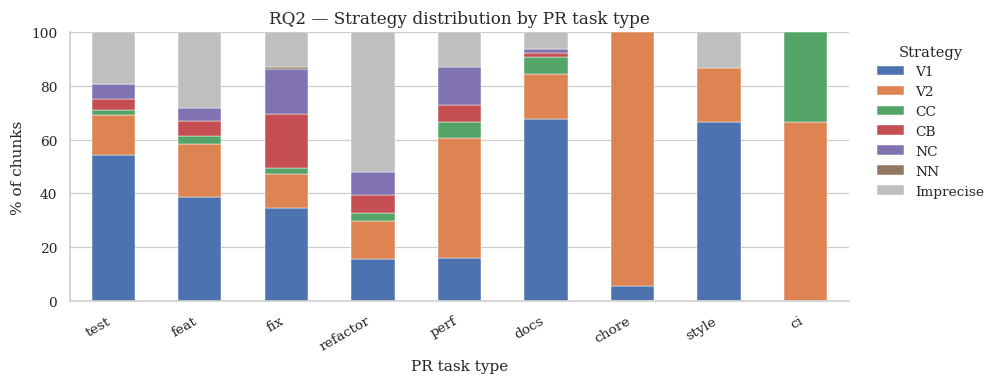

In [7]:
if not chunks.empty and "pr_task_type" in chunks.columns:
    subset = chunks.dropna(subset=["pr_task_type"]).copy()
    if subset.empty:
        print("pr_task_type is only populated under --pop-only.")
    else:
        by_task = strategy_distribution(subset, group_col="pr_task_type")
        order = subset["pr_task_type"].value_counts().index
        by_task = by_task.reindex(order)

        fig, ax = plt.subplots(figsize=(max(5, 0.8 * len(by_task) + 2), 3.6))
        (by_task * 100).plot(
            kind="bar", stacked=True,
            color=[STRATEGY_PALETTE[s] for s in STRATEGY_ORDER],
            edgecolor="white", linewidth=0.3, ax=ax,
        )
        ax.set_ylabel("% of chunks")
        ax.set_xlabel("PR task type")
        ax.set_title("RQ2 — Strategy distribution by PR task type")
        ax.set_ylim(0, 100)
        ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        save_fig(fig, "rq2_by_task_type")
        plt.show()


## 7. Per-stratum numerical tables

In [8]:
if not chunks.empty:
    for axis in ("agent", "language_top", "pr_task_type"):
        if axis not in chunks.columns:
            continue
        table = strategy_distribution(chunks, group_col=axis) * 100
        table["n"] = chunks.groupby(axis).size()
        table = table.sort_values("n", ascending=False).round(2)
        print(f"\n=== Strategy % by {axis} ===")
        print(table.to_string())



=== Strategy % by agent ===
strategy         V1     V2    CC    CB    NC    NN  Imprecise      n
agent                                                               
OpenAI_Codex  29.76  13.44  3.69  5.34  5.93  0.41      41.43  77598
Copilot       46.20  15.57  2.04  5.53  8.43  0.24      21.98  12142
Devin         23.41  31.88  3.20  8.73  7.89  0.33      24.56   4903
Cursor        23.46  14.90  2.34  8.26  8.86  0.34      41.83   2651
Claude_Code   20.82  27.24  1.75  4.77  8.07  0.19      37.16   1028

=== Strategy % by language_top ===
strategy         V1     V2    CC     CB     NC    NN  Imprecise      n
language_top                                                          
C#             2.77   4.89  2.53   2.79   1.23  0.34      85.45  25765
TypeScript    52.79  13.05  1.78   4.37   5.81  0.39      21.80  16994
Unknown       47.65  16.73  4.96   4.60   6.45  0.09      19.51  14898
C++           22.03  24.88  4.13  13.28  16.79  0.39      18.49   9003
C             54.74  14.94

---
### Outputs summary

Figures saved to `analysis/figures/`:

| File stem                  | Paper role |
|----------------------------|------------|
| `rq2_global_vs_ghiotto`    | Headline figure: agent vs. human side-by-side |
| `rq2_by_agent`             | Stratified by agent |
| `rq2_by_language`          | Stratified by language (top-N) |
| `rq2_by_task_type`         | Stratified by `pr_task_type` (AIDev-pop only) |
